In [65]:
# # 1. Gỡ cài đặt các thư viện cũ
# !pip uninstall numpy pandas prophet cmdstanpy -y

# # 2. Cài đặt đúng phiên bản (theo project gốc)
# !pip install numpy==1.26.4
# !pip install pandas==2.2.2
# !pip install lightgbm==4.3.0 optuna==3.6.1 scikit-learn==1.5.1
# !pip install matplotlib==3.6.0 seaborn==0.13.2 shap==0.44.1
#!pip install streamlit==1.35.0 joblib==1.4.2 pyarrow==20.0.0
!pip install cmdstanpy
!pip install prophet
!pip install lightgbm
!pip install optuna

: 

: 

In [ ]:
import numpy as np
import pandas as pd
import prophet
import joblib
import os
import sys
import torch

if torch.cuda.is_available():
    print(f"GPU activated: {torch.cuda.get_device_name(0)}")
else:
    print(" still CPU")

print("NumPy version:", np.__version__)      # Phải là 1.26.4
print("Pandas version:", pd.__version__)     # Phải là 2.2.2
print("Prophet version:", prophet.__version__) # Phải là 1.1.4

GPU activated: NVIDIA A100-SXM4-40GB
NumPy version: 2.0.2
Pandas version: 2.2.2
Prophet version: 1.3.0


: 

In [66]:

project_root = '/content/Walmart_sales_forecasting'
if project_root not in sys.path:
    sys.path.append(project_root)

print("Root:", project_root)

Root: /content/Walmart_sales_forecasting


: 

In [67]:
import pandas as pd
import numpy as np
import torch
import prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from src.metrics import weighted_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import joblib


: 

In [68]:
%cd /content/Walmart_sales_forecasting
data_dir = 'data/processed/feature_engineering.feather'
df_feature = pd.read_feather(data_dir)
df_feature

/content/Walmart_sales_forecasting


,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,mean_sales_last_52_week,max_sales_last_52_week,min_sales_last_52_week,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
52,1,1,2011-02-04,21665.76,151315,42.27,2.989,0.00,0.00,0.0,...,19273.916923,118957.83,67.92,27074.293465,25415.997603,14985.992658,1606629.58,22628.585634,792603.03,17613.400667
195,1,2,2011-02-04,46829.12,151315,42.27,2.989,0.00,0.00,0.0,...,19551.767308,118957.83,67.92,27022.226126,23540.878802,19995.818165,1606629.58,22628.585634,1853050.88,41178.908444
338,1,3,2011-02-04,11012.52,151315,42.27,2.989,0.00,0.00,0.0,...,20307.390962,118957.83,67.92,27228.242813,35184.999401,40120.794541,1606629.58,22628.585634,420675.49,9348.344222
481,1,4,2011-02-04,35870.49,151315,42.27,2.989,0.00,0.00,0.0,...,20251.570962,118957.83,67.92,27244.574753,23098.759700,18289.588635,1606629.58,22628.585634,1167502.15,25944.492222
624,1,5,2011-02-04,31280.62,151315,42.27,2.989,0.00,0.00,0.0,...,20860.850769,118957.83,67.92,27232.555625,29484.624850,31475.264659,1606629.58,22628.585634,1024066.58,23274.240455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,118221,58.85,3.882,4018.91,58.08,100.0,...,9460.779808,54608.75,23.92,12025.307089,35354.118359,45312.322469,760281.43,11347.484030,1049693.34,24992.698571
421146,45,94,2012-10-26,5203.31,118221,58.85,3.882,4018.91,58.08,100.0,...,9309.340577,54608.75,23.92,12063.252477,18920.959180,13193.930617,760281.43,11347.484030,1291378.41,29349.509318
421289,45,95,2012-10-26,56017.47,118221,58.85,3.882,4018.91,58.08,100.0,...,9336.483462,54608.75,23.92,12052.177317,12062.134590,7200.965154,760281.43,11347.484030,3002617.27,66724.828222
421434,45,97,2012-10-26,6817.48,118221,58.85,3.882,4018.91,58.08,100.0,...,9909.124423,56017.47,23.92,13492.432928,34039.802295,43813.343789,760281.43,11347.484030,596563.70,13558.265909


: 

In [69]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261083 entries, 52 to 421569
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Store                    261083 non-null  int64         
 1   Dept                     261083 non-null  int64         
 2   Date                     261083 non-null  datetime64[ns]
 3   Weekly_Sales             261083 non-null  float64       
 4   Size                     261083 non-null  int64         
 5   Temperature              261083 non-null  float64       
 6   Fuel_Price               261083 non-null  float64       
 7   MarkDown1                261083 non-null  float64       
 8   MarkDown2                261083 non-null  float64       
 9   MarkDown3                261083 non-null  float64       
 10  MarkDown4                261083 non-null  float64       
 11  MarkDown5                261083 non-null  float64       
 12  CPI                 

: 

# **Build Prophet**

In [ ]:
test = df_feature[df_feature['is_test']]
train = df_feature[~df_feature['is_test']]

prophet_data = df_feature.groupby(['Date', 'store_dept']).agg(
    {
        'Weekly_Sales' : 'sum',
        'Size' : 'first',
        'Type_B': 'first',         
        'Type_C': 'first',
        'IsHoliday_True' : 'first',
        'Temperature': 'first',
        'Fuel_Price' : 'first',
        "total_markdown": "first",   
        "avg_markdown": "first",      
        "max_markdown": "first",
        'lags_2' : 'first',
        'lags_4' : 'first',
        'lags_6' : 'first',
        'mean_sales_last_2_week' : 'first',
        'mean_sales_last_4_week' : 'first',
        'mean_sales_last_6_week' : 'first',
    }
).reset_index()

# Giả sử IsHoliday_True là 0 hoặc 1, total_markdown là một số
prophet_data['holiday_markdown'] = prophet_data['IsHoliday_True'] * prophet_data['total_markdown']

prophet_data

,Date,store_dept,Weekly_Sales,Size,Type_B,Type_C,IsHoliday_True,Temperature,Fuel_Price,total_markdown,avg_markdown,max_markdown,lags_2,lags_4,lags_6,mean_sales_last_2_week,mean_sales_last_4_week,mean_sales_last_6_week,holiday_markdown
0,2011-02-04,store_10_dept_1,36145.83,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,30911.87,26041.71,140537.20,2745.320,22452.3400,23377.220000,0.0
1,2011-02-04,store_10_dept_10,43559.36,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,38277.23,43303.01,56874.92,75402.450,49673.0525,51088.651667,0.0
2,2011-02-04,store_10_dept_11,34892.54,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,27625.28,41213.41,41524.43,50683.840,58722.9475,49604.863333,0.0
3,2011-02-04,store_10_dept_12,8071.33,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,8052.11,6674.82,7185.88,39225.950,57314.2000,46190.685000,0.0
4,2011-02-04,store_10_dept_13,66266.75,126512,True,False,False,44.88,3.348,0.00,0.000,0.00,63178.64,64917.14,57546.77,21481.935,36082.8875,46309.276667,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261078,2012-10-26,store_9_dept_91,914.84,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,698.84,998.95,1043.68,7728.250,6653.1025,6973.853333,0.0
261079,2012-10-26,store_9_dept_92,18310.28,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,20285.74,18333.69,18600.46,2005.805,4241.2575,5020.003333,0.0
261080,2012-10-26,store_9_dept_94,233.02,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,3.88,10.62,116.12,9612.560,8670.4050,7639.588333,0.0
261081,2012-10-26,store_9_dept_95,32382.05,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,32072.80,33119.87,34591.81,9271.650,5638.7275,5918.055000,0.0


: 

In [ ]:
#handle missing case
regressor_cols = ['Type_B', 'Type_C', 'IsHoliday_True', 'Temperature', 'Fuel_Price', 'total_markdown']
prophet_data[regressor_cols] = prophet_data[regressor_cols].fillna(0)

: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


: 

In [ ]:
def build_prophet_model(prophet_data,  test_data, checkpoint_dir="/content/drive/MyDrive/Walmart_checkpoints"):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    min_test_time = test_data['Date'].min()
    max_test_time = test_data['Date'].max()
    
    prophet_model = {}
    prophet_predictions = {}
    prophet_metrics = pd.DataFrame(columns=['combo', 'mae', 'rmse', 'wape'])
    all_real = []
    all_predict = [] 
    
    scale_cols = ['Size', 'Temperature', 'Fuel_Price', 'total_markdown', 
                'lags_2', 'lags_4', 'lags_6',  
                'mean_sales_last_2_week', 'mean_sales_last_4_week', 'mean_sales_last_6_week',
                'holiday_markdown']
    
    for combination in prophet_data['store_dept'].unique():
        print(f'Build prophet model for {combination}')
        
        model_path = os.path.join(checkpoint_dir,f"{combination}_model.pkl")
        forecast_path = os.path.join(checkpoint_dir,f"{combination}_forecast.csv")
        scaler_path = os.path.join(checkpoint_dir, f"{combination}_scaler.pkl")
        
        if os.path.exists(model_path) and os.path.exists(forecast_path):
            print(f"Load existing {combination}")
            model = joblib.load(model_path)
            forecast = pd.read_csv(forecast_path, parse_dates=['ds'])
            scaler = joblib.load(scaler_path)
            prophet_model[combination] = model
            prophet_predictions[combination] = forecast
            
            # recalc metrics
            mae = mean_absolute_error(forecast['y'], forecast['yhat'])
            rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
            wape = weighted_absolute_percentage_error(forecast['y'], forecast['yhat'])
            prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wape]
            all_real.extend(forecast['y'])
            all_predict.extend(forecast['yhat'])
            continue
        
        combo = prophet_data[prophet_data['store_dept'] == combination].copy()
        combo = combo.rename(columns={'Date':'ds', 'Weekly_Sales' : 'y'}) #prophet require ds and y
        
        combo_train = combo[combo['ds'] < min_test_time]
        combo_test = combo[(combo['ds'] >= min_test_time) & (combo['ds'] <= max_test_time)]
        if combo_train.empty or combo_test.empty:
            print(f'Skip {combination} due to lack of data')
            continue
        
        # standardize value for model to learn
        available_cols = [col for col in scale_cols if col in combo_train.columns] 
        scaler = StandardScaler()
        if available_cols:
            scaler.fit(combo_train[available_cols])
            combo_train.loc[:, available_cols] = scaler.transform(combo_train[available_cols])
            combo_test.loc[:, available_cols] = scaler.transform(combo_test[available_cols])
        else:
            scaler = None
        
        # mulitplicative is not suitable for low sales due to being sensitive to changes
        if combo_train['y'].mean() < 50:
            model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True, seasonality_mode='additive', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)
        else:
            model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True, seasonality_mode='multiplicative', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)    
        
        #add regressor to learn
        regressors = ['Type_B', 'Type_C', 'IsHoliday_True'] + available_cols    
        for reg in regressors:
            if reg in combo_train.columns:
                model.add_regressor(reg)
        
        try:
            model.fit(combo_train)
        except Exception as e:
            print(f'Fail to train {combination} : {e}')
            continue
        
        # test
        future = combo_test[['ds'] + regressors]
        forecast = model.predict(future)
        
        forecast = forecast[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].merge(combo_test[['ds', 'y']], on=['ds'])
        
        #save checkpoint
        joblib.dump(model, model_path)
        forecast.to_csv(forecast_path, index=False)
        if scaler is not None:
                    joblib.dump(scaler, scaler_path)
        print(f"Saved checkpoint for {combination}")
        
        prophet_model[combination] = model
        prophet_predictions[combination] = forecast
        
        # evaluate
        mae = mean_absolute_error(forecast['y'], forecast['yhat'])
        rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
        
        wampe = weighted_absolute_percentage_error(forecast['y'], forecast['yhat']).item()
        
        prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wampe]
        
        #overall evaluation
        all_real.extend(forecast['y'])
        all_predict.extend(forecast['yhat'])
        
    
    mean_mae = np.mean(prophet_metrics['mae'])
    mean_rmse = np.mean(prophet_metrics['rmse'])
    ovr_wampe = weighted_absolute_percentage_error(all_real, all_predict)
    
    return prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe)


prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe) = build_prophet_model(prophet_data, test)
    
        
    

Build prophet model for  store_10_dept_1
Load existing  store_10_dept_1
Build prophet model for  store_10_dept_10
Load existing  store_10_dept_10
Build prophet model for  store_10_dept_11
Load existing  store_10_dept_11
Build prophet model for  store_10_dept_12
Load existing  store_10_dept_12
Build prophet model for  store_10_dept_13
Load existing  store_10_dept_13
Build prophet model for  store_10_dept_14
Load existing  store_10_dept_14
Build prophet model for  store_10_dept_16
Load existing  store_10_dept_16
Build prophet model for  store_10_dept_17
Load existing  store_10_dept_17
Build prophet model for  store_10_dept_19
Load existing  store_10_dept_19
Build prophet model for  store_10_dept_2
Load existing  store_10_dept_2
Build prophet model for  store_10_dept_20
Load existing  store_10_dept_20
Build prophet model for  store_10_dept_21
Load existing  store_10_dept_21
Build prophet model for  store_10_dept_22
Load existing  store_10_dept_22
Build prophet model for  store_10_dept_23


: 

In [ ]:
print(
    f"Prophet Model Results:\nMAE: {mean_mae:.2f} | RMSE: {mean_rmse:.2f} | WAPE: {ovr_wampe:.2f}"
)

Prophet Model Results:
MAE: 2424.97 | RMSE: 2908.24 | WAPE: 0.16


: 

In [ ]:
%cd /content/drive/MyDrive/Walmart_checkpoints
!ls


/content/drive/MyDrive/Walmart_checkpoints
' store_10_dept_10_forecast.csv'  ' store_2_dept_3_scaler.pkl'
' store_10_dept_10_model.pkl'	  ' store_2_dept_40_forecast.csv'
' store_10_dept_10_scaler.pkl'	  ' store_2_dept_40_model.pkl'
' store_10_dept_11_forecast.csv'  ' store_2_dept_40_scaler.pkl'
' store_10_dept_11_model.pkl'	  ' store_2_dept_41_forecast.csv'
' store_10_dept_11_scaler.pkl'	  ' store_2_dept_41_model.pkl'
' store_10_dept_12_forecast.csv'  ' store_2_dept_41_scaler.pkl'
' store_10_dept_12_model.pkl'	  ' store_2_dept_42_forecast.csv'
' store_10_dept_12_scaler.pkl'	  ' store_2_dept_42_model.pkl'
' store_10_dept_13_forecast.csv'  ' store_2_dept_42_scaler.pkl'
' store_10_dept_13_model.pkl'	  ' store_2_dept_44_forecast.csv'
' store_10_dept_13_scaler.pkl'	  ' store_2_dept_44_model.pkl'
' store_10_dept_14_forecast.csv'  ' store_2_dept_44_scaler.pkl'
' store_10_dept_14_model.pkl'	  ' store_2_dept_45_forecast.csv'
' store_10_dept_14_scaler.pkl'	  ' store_2_dept_45_model.pkl'
' store_

: 

In [ ]:
# Gộp tất cả dự báo thành một DataFrame
all_forecasts = pd.concat(prophet_predictions.values(), ignore_index=True)
print(all_forecasts.head())

          ds          yhat    yhat_upper    yhat_lower         y
0 2012-08-10  23461.596353  39608.924760   8357.801960  26320.29
1 2012-08-17  23896.241074  39018.667466   7749.277707  26752.40
2 2012-08-24  25375.886630  40490.833214   9857.930037  26804.84
3 2012-08-31  29779.830231  44182.642878  14568.143687  26083.28
4 2012-09-07  20174.235429  34867.755726   5227.258808  29426.33


: 

In [ ]:
import importlib
import src.plots
importlib.reload(src.plots)
from src.plots import visualize_pred, plot_prophet_comparison

df_prophet_pred = visualize_pred(prophet_predictions)
print(df_prophet_pred)

              ds          yhat    yhat_upper    yhat_lower         y  \
0     2012-08-10  23461.596353  39608.924760   8357.801960  26320.29   
1     2012-08-17  23896.241074  39018.667466   7749.277707  26752.40   
2     2012-08-24  25375.886630  40490.833214   9857.930037  26804.84   
3     2012-08-31  29779.830231  44182.642878  14568.143687  26083.28   
4     2012-09-07  20174.235429  34867.755726   5227.258808  29426.33   
...          ...           ...           ...           ...       ...   
35504 2012-08-31     57.961151     57.961152     57.961151      5.00   
35505 2012-09-14    235.267711    235.267712    235.267710      5.00   
35506 2012-09-28    378.769453    378.769455    378.769451      3.75   
35507 2012-10-05    336.777552    336.777554    336.777550      3.75   
35508 2012-10-12    215.677153    215.677156    215.677150      4.00   

              store_dept  
0        store_10_dept_1  
1        store_10_dept_1  
2        store_10_dept_1  
3        store_10_dept_1  


: 

In [ ]:
# df_prophet_pred.groupby('store_dept').count().reset_index()
# df_prophet_pred

,ds,yhat,yhat_upper,yhat_lower,y,store_dept
0,2012-08-10,23461.596353,39608.924760,8357.801960,26320.29,store_10_dept_1
1,2012-08-17,23896.241074,39018.667466,7749.277707,26752.40,store_10_dept_1
2,2012-08-24,25375.886630,40490.833214,9857.930037,26804.84,store_10_dept_1
3,2012-08-31,29779.830231,44182.642878,14568.143687,26083.28,store_10_dept_1
4,2012-09-07,20174.235429,34867.755726,5227.258808,29426.33,store_10_dept_1
...,...,...,...,...,...,...
35504,2012-08-31,57.961151,57.961152,57.961151,5.00,store_36_dept_32
35505,2012-09-14,235.267711,235.267712,235.267710,5.00,store_36_dept_32
35506,2012-09-28,378.769453,378.769455,378.769451,3.75,store_36_dept_32
35507,2012-10-05,336.777552,336.777554,336.777550,3.75,store_36_dept_32


: 

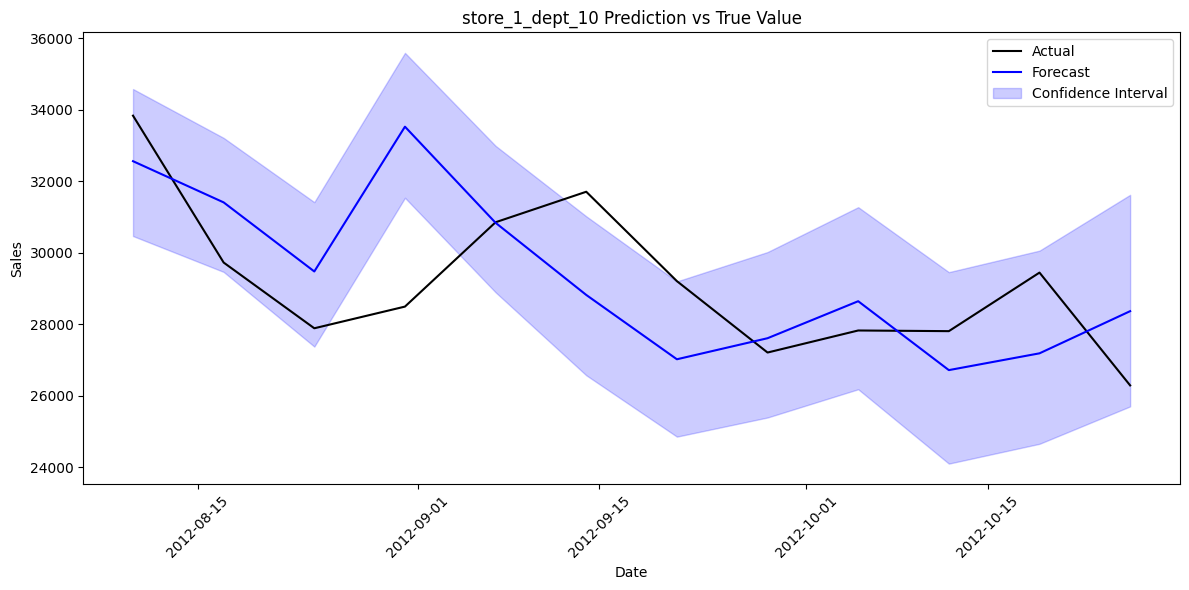

: 

In [ ]:
# plot_prophet_comparison(df_prophet_pred, store_dept='store_1_dept_10')

# **Build LightGBM**

In [ ]:
cols_to_drop = ['Date', 'store_dept', 'Weekly_Sales', 'is_test'] # do not drop dept and store column so that model can learn unique pattern of specific ones

X_train = df_feature[~df_feature['is_test']].drop(cols_to_drop, axis=1)
y_train = df_feature[~df_feature['is_test']]['Weekly_Sales']

X_test = df_feature[df_feature['is_test']].drop(cols_to_drop, axis=1)
y_test = df_feature[df_feature['is_test']]['Weekly_Sales']

X_train


,Store,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,mean_sales_last_52_week,max_sales_last_52_week,min_sales_last_52_week,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
52,1,1,151315,42.27,2.989,0.00,0.00,0.00,0.00,0.00,...,19273.916923,118957.83,67.92,27074.293465,25415.997603,14985.992658,1606629.58,22628.585634,792603.03,17613.400667
195,1,2,151315,42.27,2.989,0.00,0.00,0.00,0.00,0.00,...,19551.767308,118957.83,67.92,27022.226126,23540.878802,19995.818165,1606629.58,22628.585634,1853050.88,41178.908444
338,1,3,151315,42.27,2.989,0.00,0.00,0.00,0.00,0.00,...,20307.390962,118957.83,67.92,27228.242813,35184.999401,40120.794541,1606629.58,22628.585634,420675.49,9348.344222
481,1,4,151315,42.27,2.989,0.00,0.00,0.00,0.00,0.00,...,20251.570962,118957.83,67.92,27244.574753,23098.759700,18289.588635,1606629.58,22628.585634,1167502.15,25944.492222
624,1,5,151315,42.27,2.989,0.00,0.00,0.00,0.00,0.00,...,20860.850769,118957.83,67.92,27232.555625,29484.624850,31475.264659,1606629.58,22628.585634,1024066.58,23274.240455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421000,45,93,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,9023.586346,55100.78,-1.91,11959.182352,31767.816389,40144.232916,725729.51,10517.818986,1177581.75,28037.660714
421134,45,94,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,8559.113462,55100.78,-1.91,11687.992754,17626.748194,12650.318229,725729.51,10517.818986,1410974.73,35274.368250
421277,45,95,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,8435.615577,55100.78,-1.91,11696.696569,11052.484097,6521.244557,725729.51,10517.818986,3411164.17,75803.648222
421422,45,97,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,9126.529615,55100.78,-1.91,13181.244801,32005.307049,41348.908639,725729.51,10517.818986,671580.72,15263.198182


: 

In [71]:
import lightgbm as lgbm
from sklearn.model_selection import TimeSeriesSplit

def build_lightgbm(X_train, y_train, X_test, y_test):
    print('Building LightGBM model...')
    
    tss = TimeSeriesSplit(n_splits=5)
    
    #default param of lgbm
    param = {
        'objective' : 'regression',
        'metric' : 'rmse',
        'boosting_type' : 'gbdt',
        'num_leaves' : 31,
        'learning_rate' : 0.1,
        'feature_fraction' : 0.9,
        'n_estimators' : 100,
        'verbose' : -1, 
    }
    
    model = lgbm.LGBMRegressor(**param)
    cr_val = []
    
    for train_idx, val_idx in tss.split(X_train):
        X_train_cv = X_train.iloc[train_idx]
        y_train_cv =  y_train.iloc[train_idx]
        X_val_cv = X_train.iloc[val_idx]
        y_val_cv = y_train.iloc[val_idx]
        
        model.fit(
            X_train_cv,
            y_train_cv,
            eval_set=[(X_val_cv, y_val_cv)],
            categorical_feature=['Store', 'Dept']
        )
        
        pred = model.predict(X_val_cv)
        
        mae = mean_absolute_error(y_val_cv, pred)
        rmse = np.sqrt(mean_squared_error(y_val_cv, pred))
        wape = weighted_absolute_percentage_error(y_val_cv, pred)
        
        cr_val.append((mae, rmse, wape))
        
    avg_mae, avg_rmse, avg_wape = np.mean(cr_val, axis=0)
    print(f'Model Result:\n MAE : {avg_mae} | RMSE : {avg_rmse} | WAPE : {avg_wape}')
    
    #Test model
    print('Building Test Model..')
    test_model = lgbm.LGBMRegressor(**param)
    test_model.fit(X_train, y_train)
    test_pred = test_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_wape = weighted_absolute_percentage_error(y_test, test_pred)
    df_test = df_feature[df_feature['is_test']].copy()
    df_test['y_true'] = y_test.values
    df_test['y_pred'] = test_pred
    df_test['error'] = np.abs(df_test['y_true'] - df_test['y_pred'])

    top_errors = df_test.sort_values('error', ascending=False).head(15)
    print(top_errors[['Date', 'Store', 'Dept', 'y_true', 'y_pred', 'error']])
    
    print(f'Test Model Result:\n MAE : {test_mae} | RMSE : {test_rmse} | WAPE : {test_wape}')
    
    return test_model, (test_mae, test_rmse, test_wape)
    
    
lgbm_model, (lgbm_mae, lgbm_rmse, lgbm_wape) = build_lightgbm(X_train, y_train, X_test, y_test)

Building LightGBM model...
Model Result:
 MAE : 1577.6544552447965 | RMSE : 3782.326351155198 | WAPE : 0.09504160234748224
Building Test Model..


ValueError: train and valid dataset categorical_feature do not match.

: 

# **Finetune LightGBM**

In [ ]:
import optuna
def optimizing_lgbm(X_train, y_train, X_test, y_test):
    
    print('Optimizing LightGBM with optuna..')
    
    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "num_leaves": trial.suggest_int("num_leaves", 15, 50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "n_estimators": 1000,
            "verbose": -1,
        }
        
        model = lgbm.LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[lgbm.early_stopping(stopping_rounds=50)]
        )
        pred = model.predict(X_test)
       
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        return rmse
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    best_params = study.best_params
    # best param only return the param found, not the fixed one so we have to add fixed param to match
    best_params.update(
        {
            'objective' : 'regression',
            'metric' : 'rmse',
            'boosting_type' : 'gbdt',
            'verbose' : -1,
        }
    )
    
    print(f'Best params:\n')
    for key, value in best_params.items():
        print(f'{key} : {value}')
        
    final_model = lgbm.LGBMRegressor(**best_params)
    final_model.fit(X_train, y_train)
    final_pred = final_model.predict(X_test)
    final_mae = mean_absolute_error(y_test, final_pred)
    final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
    final_wape = weighted_absolute_percentage_error(y_test, final_pred)
    
    print(f'Optimized LightGBM Model:\n MAE : {final_mae} | RMSE : {final_rmse} | WAPE : {final_wape}')
    
    return final_model, (final_mae, final_rmse, final_wape)


opt_model, (opt_mae, opt_rmse, opt_wape) = optimizing_lgbm(X_train, y_train, X_test, y_test)
    
    
    
    
    

[I 2026-08-09 17:00:39,966] A new study created in memory with name: no-name-4ad28b5a-7eb3-4310-a816-9d4afa958dd8


Optimizing LightGBM with optuna..
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 2994.97


[I 2026-08-09 17:00:51,069] Trial 0 finished with value: 2994.969924909204 and parameters: {'num_leaves': 35, 'learning_rate': 0.014576321569822033, 'feature_fraction': 0.8234194691713241, 'bagging_fraction': 0.8925341088130703, 'bagging_freq': 1, 'min_child_samples': 27}. Best is trial 0 with value: 2994.969924909204.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 2846.72


[I 2026-08-09 17:01:02,495] Trial 1 finished with value: 2846.7184221169864 and parameters: {'num_leaves': 31, 'learning_rate': 0.038418573008058815, 'feature_fraction': 0.965456692146953, 'bagging_fraction': 0.8453491640983428, 'bagging_freq': 4, 'min_child_samples': 27}. Best is trial 1 with value: 2846.7184221169864.


...

[I 2026-08-09 17:10:20,919] Trial 48 finished with value: 2667.2706535916977 and parameters: {'num_leaves': 45, 'learning_rate': 0.08895797470666372, 'feature_fraction': 0.9360137794718109, 'bagging_fraction': 0.7550570308998417, 'bagging_freq': 10, 'min_child_samples': 18}. Best is trial 44 with value: 2647.3560609137076.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 2809.92


[I 2026-08-09 17:10:33,003] Trial 49 finished with value: 2809.917287723965 and parameters: {'num_leaves': 50, 'learning_rate': 0.025766973837055306, 'feature_fraction': 0.8942027627421776, 'bagging_fraction': 0.987637147858203, 'bagging_freq': 1, 'min_child_samples': 25}. Best is trial 44 with value: 2647.3560609137076.


Best params:

num_leaves : 48
learning_rate : 0.09217671609251067
feature_fraction : 0.735842610276919
bagging_fraction : 0.9993476675090911
bagging_freq : 3
min_child_samples : 21
objective : regression
metric : rmse
boosting_type : gbdt
verbose : -1
Optimized LightGBM Model:
 MAE : 1512.3200663889515 | RMSE : 3026.151331409454 | WAPE : 0.09691203539474222


: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def evaluate_model(model, X_test, y_test, data):
    """
    Evaluate the model performance on the test set (last 3 months of 2017)
    """
    print("\nEvaluating model performance on test set...")

    # Make predictions on the test set
    test_preds = model.predict(X_test)

    # Calculate metrics
    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_wape = weighted_absolute_percentage_error(y_test, test_preds)

    # Print evaluation results
    print(f"Final Model Test Evaluation:")
    print(f"    MAE: {test_mae:.2f}")
    print(f"    RMSE: {test_rmse:.2f}")
    print(f"    WAPE: {test_wape:.2f}%")

    # Analyze errors by time period (month)
    test_results = data[data["is_test"]].copy()
    test_results["prediction"] = test_preds
    test_results["error"] = test_results["sales"] - test_results["prediction"]
    test_results["abs_error"] = np.abs(test_results["error"])
    test_results["month_name"] = test_results["date"].dt.strftime("%B")
    
    # Summarize errors by month
    monthly_errors = (
        test_results.groupby("month_name")
        .agg({"abs_error": "mean", "error": "mean", "sales": "mean"})
        .reset_index()
    )
    monthly_errors["error_pct"] = (
        100 * monthly_errors["abs_error"] / monthly_errors["sales"]
    )

    print("\nError Analysis by Month:")
    print(
        monthly_errors[["month_name", "abs_error", "error_pct"]].to_string(index=False)
    )

    # Store results for visualization
    # Include month and store information for granular analysis
    test_results["year_month"] = test_results["date"].dt.strftime("%Y-%m")

    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, test_preds, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "r--")
    plt.title("Actual vs Predicted Sales (Test Set)")
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.tight_layout()
    # plt.savefig('actual_vs_predicted_test.png')
    
    # Plot error distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(test_results["error"], kde=True)
    plt.title("Error Distribution")
    plt.xlabel("Prediction Error")
    plt.tight_layout()
    # plt.savefig('error_distribution.png')

    return test_mae, test_rmse, test_wape, test_preds, y_test, test_results



: 

In [ ]:
test_mae, test_rmse, test_smape, test_preds, y_test_values, test_results = (
    evaluate_model(opt_model, X_test, y_test, df_feature)
)

: 

In [ ]:
import os
import pickle
import json
import numpy as np
import pandas as pd

def save_lightgbm_model(model, X_train, output_dir="../models", model_version="1.0.0"):
    """
    Save LightGBM model and all necessary metadata for inference.
    
    Args:
        model: Trained LightGBM model
        X_train: DataFrame used for training (to extract feature names and dtypes)
        output_dir: Directory to save model artifacts
        model_version: Version string
    """
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving LightGBM model to: {os.path.abspath(output_dir)}")
    
    # 1. Save model
    model_path = os.path.join(output_dir, "sales_forecast_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"✅ Model saved to {model_path}")

    # 2. Feature names and types
    feature_names = X_train.columns.tolist()
    feature_dtypes = X_train.dtypes.astype(str).to_dict()

    # 3. Build metadata
    feature_stats = {
        "model_version": model_version,
        "last_trained": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "required_columns": feature_names,
        "column_order": feature_names,
        "column_dtypes": feature_dtypes,
        "default_values": {
            # Các giá trị mặc định cho các feature thời gian, có thể tính từ ngày dự báo
            "year": 2017,
            "month": 1,
            "day": 1,
            "day_of_week": 0,
            "is_weekend": 0,
            "quarter": 1,
            "is_holiday": 0,
            # Nếu bạn có các feature khác có thể suy ra hoặc đặt mặc định
            "Temperature": 60.0,  # nhiệt độ trung bình
            "Fuel_Price": 2.5,
            "CPI": 200.0,
            "Unemployment": 8.0,
            "total_markdown": 0.0,
            "avg_markdown": 0.0,
            "max_markdown": 0.0,
            "holiday_markdown": 0.0,
            # Các lag và rolling có thể không có mặc định vì cần tính từ dữ liệu quá khứ
        },
        "temperature_bins": [-np.inf, 20, 25, 30, np.inf],
        "temperature_labels": ["Cold", "Cool", "Warm", "Hot"],
        "humidity_bins": [-np.inf, 60, 75, np.inf],  # nếu bạn có humidity
        "humidity_labels": ["Low", "Medium", "High"],
        "scalers": None  # Nếu bạn đã chuẩn hóa features, lưu scaler vào đây
    }
    
    # Nếu bạn đã dùng StandardScaler, bạn có thể lưu nó
    if hasattr(model, 'scaler_'):
        scaler = model.scaler_  # giả sử bạn đã gán scaler cho model
        feature_stats["scalers"] = {
            "mean": scaler.mean_.tolist(),
            "scale": scaler.scale_.tolist()
        }

    # 4. Save metadata
    stats_pkl_path = os.path.join(output_dir, "feature_stats.pkl")
    with open(stats_pkl_path, "wb") as f:
        pickle.dump(feature_stats, f)
    print(f"Metadata (pickle) saved to {stats_pkl_path}")
    
    # 5. Save human-readable JSON version
    stats_json_path = os.path.join(output_dir, "feature_stats.json")
    # Convert numpy types to Python types for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, pd.Timestamp):
            return str(obj)
        else:
            return obj

    with open(stats_json_path, "w") as f:
        json.dump(feature_stats, f, indent=2, default=convert_to_serializable)
    print(f"Metadata (JSON) saved to {stats_json_path}")

    print("Model and metadata saved successfully!")
    return model_path, stats_pkl_path

: 

In [ ]:
# Save model
drive_model_dir = "/content/drive/MyDrive/Walmart_models"

save_lightgbm_model(
    model=opt_model,
    X_train=X_train,
    feature_names=X_train.columns,
    output_dir=drive_model_dir
)

: 